In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "creditcard.csv"))

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df = df.drop(columns=['Amount', 'Time'])
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [4]:
df.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [5]:
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Column '{col}' has non-numerical data type: {df[col].dtype}")
if all(pd.api.types.is_numeric_dtype(df[col]) for col in df.columns):
    print("All columns in the DataFrame are numerical.")

All columns in the DataFrame are numerical.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 29 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

/tmp/ipykernel_14838/2063575226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


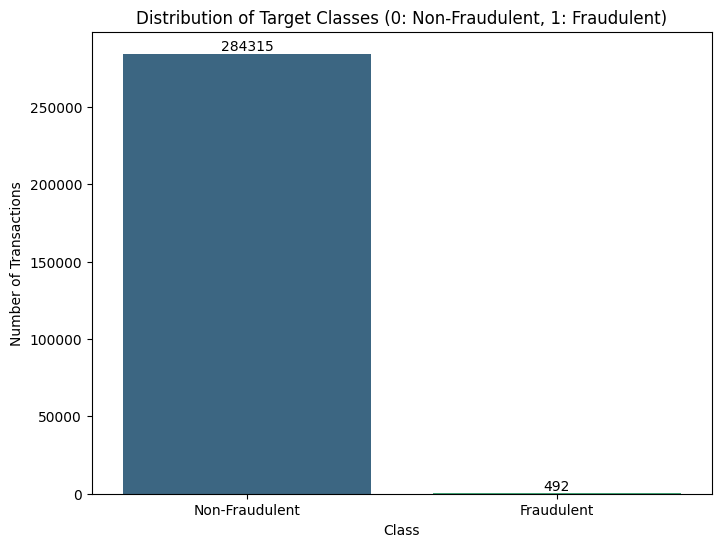

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each class
class_counts = df['Class'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Target Classes (0: Non-Fraudulent, 1: Fraudulent)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])

# Add count labels on top of the bars
for index, value in enumerate(class_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Separate features (X) and target (y) from the DataFrame
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Separate non-fraudulent (Class 0) and fraudulent (Class 1) data
X_normal = X[y == 0]
y_normal = y[y == 0]

X_fraud = X[y == 1]
y_fraud = y[y == 1]

print(f"Original Non-Fraudulent Data Shape (X_normal): {X_normal.shape}")
print(f"Original Fraudulent Data Shape (X_fraud): {X_fraud.shape}")

# 3. Split non-fraudulent data into training and validation sets for the Autoencoder
# These will serve as the 'normal' data for AE training and validation.
X_train_normal, X_val_normal, y_train_normal, y_val_normal = train_test_split(
    X_normal, y_normal, test_size=0.2, random_state=42
)

# 4. The entire fraudulent data is designated as the test set for anomalies
X_test_fraud = X_fraud
y_test_fraud = y_fraud

print(f"Autoencoder Training (Normal) Shape (X_train_normal): {X_train_normal.shape}")
print(f"Autoencoder Validation (Normal) Shape (X_val_normal): {X_val_normal.shape}")
print(f"Fraudulent Test Data Shape (X_test_fraud): {X_test_fraud.shape}")

# 5. Initialize StandardScaler and fit ONLY on the non-fraudulent training data
scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)

# Transform the other sets using the scaler fitted on the training data
X_val_normal_scaled = scaler.transform(X_val_normal)
X_test_fraud_scaled = scaler.transform(X_test_fraud)

# Assign to variables compatible with previous autoencoder definition/training logic
X_train_major_scaled = X_train_normal_scaled # For AE training
X_val_major_scaled = X_val_normal_scaled     # For AE validation
X_minor_scaled = X_test_fraud_scaled         # All fraudulent data, scaled

# Prepare a combined evaluation set for anomaly detection performance (e.g., confusion matrix)
# This set consists of the non-fraudulent validation data and the entire fraudulent test data.
X_combined_eval_scaled = pd.concat([pd.DataFrame(X_val_normal_scaled), pd.DataFrame(X_test_fraud_scaled)], ignore_index=True)
y_combined_eval = pd.concat([y_val_normal, y_test_fraud], ignore_index=True)

print(f"\nScaled Data Shapes:")
print(f"X_train_major_scaled (AE Training): {X_train_major_scaled.shape}")
print(f"X_val_major_scaled (AE Validation): {X_val_major_scaled.shape}")
print(f"X_minor_scaled (Fraudulent Test): {X_minor_scaled.shape}")
print(f"X_combined_eval_scaled (Combined for Final Evaluation): {X_combined_eval_scaled.shape}")
print(f"y_combined_eval (Combined for Final Evaluation): {y_combined_eval.shape}")

# Also explicitly keep track of the unscaled train and validation splits for normal data for clarity
# and for potential use if needed in plotting or other tasks.
X_train = X_train_normal # Unscaled non-fraudulent training data
y_train = y_train_normal

X_val = X_val_normal     # Unscaled non-fraudulent validation data
y_val = y_val_normal

# Note: For subsequent confusion matrix calculations, when evaluating the 'validation/test set',
# you should use X_combined_eval_scaled and y_combined_eval.

Original Non-Fraudulent Data Shape (X_normal): (284315, 28)
Original Fraudulent Data Shape (X_fraud): (492, 28)
Autoencoder Training (Normal) Shape (X_train_normal): (227452, 28)
Autoencoder Validation (Normal) Shape (X_val_normal): (56863, 28)
Fraudulent Test Data Shape (X_test_fraud): (492, 28)

Scaled Data Shapes:
X_train_major_scaled (AE Training): (227452, 28)
X_val_major_scaled (AE Validation): (56863, 28)
X_minor_scaled (Fraudulent Test): (492, 28)
X_combined_eval_scaled (Combined for Final Evaluation): (57355, 28)
y_combined_eval (Combined for Final Evaluation): (57355,)


In [9]:
from sklearn.ensemble import IsolationForest
import numpy as np

print(f"Original shape of X_train_major_scaled: {X_train_major_scaled.shape}")
print(f"Original shape of y_train_normal: {y_train_normal.shape}")

# Initialize Isolation Forest model
# contamination: The proportion of outliers in the data set.
# A reasonable estimate can be based on the known fraud rate if treating non-fraudulent outliers.
# For now, let's assume a small percentage of outliers in the 'normal' training data, e.g., 1%
# This value might need tuning.
iso_forest = IsolationForest(random_state=42, contamination=0.01)

# Fit on the scaled non-fraudulent training data and predict outliers
# -1 for outliers, 1 for inliers
outlier_preds = iso_forest.fit_predict(X_train_major_scaled)

# Filter out the outliers
X_train_major_scaled_cleaned = X_train_major_scaled[outlier_preds == 1]
y_train_normal_cleaned = y_train_normal[outlier_preds == 1]

# Update the original variables with the cleaned data
X_train_major_scaled = X_train_major_scaled_cleaned
y_train_normal = y_train_normal_cleaned

# Also update the unscaled version for consistency if it's used elsewhere
X_train_normal = X_train_normal[outlier_preds == 1]
X_train = X_train_normal # Keep X_train updated as well


num_outliers_removed = np.sum(outlier_preds == -1)

print(f"\nNumber of outliers removed from training data: {num_outliers_removed}")
print(f"New shape of X_train_major_scaled: {X_train_major_scaled.shape}")
print(f"New shape of y_train_normal: {y_train_normal.shape}")

Original shape of X_train_major_scaled: (227452, 28)
Original shape of y_train_normal: (227452,)

Number of outliers removed from training data: 2275
New shape of X_train_major_scaled: (225177, 28)
New shape of y_train_normal: (225177,)


In [10]:
# Standardization has already been applied in cell Mt2-zkGzMEkY.
# The scaled datasets are available as:
# X_train_major_scaled
# X_val_major_scaled
# X_minor_scaled
# X_combined_eval_scaled

# You can verify the scaling by inspecting their values or statistics if needed.
# For example:
# import pandas as pd
# print('Mean of X_train_major_scaled:', pd.DataFrame(X_train_major_scaled).mean().mean())
# print('Std Dev of X_train_major_scaled:', pd.DataFrame(X_train_major_scaled).std().mean())

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Define input dimension (number of features)
input_dim = X_train_major_scaled.shape[1]

# Encoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation="elu")(input_layer)
encoder = Dense(8, activation="elu")(encoder)

# Bottleneck layer
bottleneck = Dense(4, activation="elu", name="bottleneck")(encoder)

# Decoder
decoder = Dense(8, activation="elu")(bottleneck)
decoder = Dense(16, activation="elu")(decoder)
output_layer = Dense(input_dim, activation="linear")(decoder) # Changed activation to linear

# Autoencoder Model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Display the model summary
autoencoder.summary()

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    mode='min',         # The training will stop when the monitored quantity stops decreasing
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the autoencoder
history = autoencoder.fit(
    X_train_major_scaled, X_train_major_scaled, # Input and target are the same for autoencoders
    epochs=20,                                  # User-specified number of epochs
    batch_size=32,                              # Batch size
    shuffle=True,                               # Shuffle data before each epoch
    validation_data=(X_val_major_scaled, X_val_major_scaled), # Validation data
    callbacks=[early_stopping],
    verbose=1
)

print("\nAutoencoder training complete.")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 28)             │           476 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296 (5.06 KB)

 Trainable params: 1,296 (5.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 0.5659 - val_loss: 0.6711
Epoch 2/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.4818 - val_loss: 0.6437
Epoch 3/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.4640 - val_loss: 0.6307
Epoch 4/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.4499 - val_loss: 0.6077
Epoch 5/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.4299 - val_loss: 0.5857
Epoch 6/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.4196 - val_loss: 0.5787
Epoch 7/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.4141 - val_loss: 0.5737
Epoch 8/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.4095 - val_loss: 0.5677
Epoch 9/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.4049 - val_loss: 0.5628
Epoch 10/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.3985 - val_loss: 0.5557
Epoch 11/20
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.3916 - val_loss: 0.5494
Epoch 12/20
7037/70

7037/7037 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Calculated Anomaly Threshold (95th percentile of training MSE): 1.0293

--- Evaluation on Training Data (Cleaned Non-Fraudulent) ---
7037/7037 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Confusion Matrix (Training Data):
[[213918  11259]
 [     0      0]]

Classification Report (Training Data):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.95      0.97    225177
 Anomaly (1)       0.00      0.00      0.00         0

    accuracy                           0.95    225177
   macro avg       0.50      0.47      0.49    225177
weighted avg       1.00      0.95      0.97    225177


--- Evaluation on Validation Data (Non-Fraudulent) ---
  72/1777 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1777/1777 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Confusion Matrix (Validation Data):
[[53500  3363]
 [    0     0]]

Classification Report (Validation Data):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.94      0.97     56863
 Anomaly (1)       0.00      0.00      0.00         0

    accuracy                           0.94     56863
   macro avg       0.50      0.47      0.48     56863
weighted avg       1.00      0.94      0.97     56863


--- Evaluation on Combined Evaluation Data (Validation + Fraudulent Test) ---
  73/1793 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1793/1793 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Confusion Matrix (Combined Evaluation Data):
[[53500  3363]
 [   79   413]]

Classification Report (Combined Evaluation Data):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.94      0.97     56863
   Fraud (1)       0.11      0.84      0.19       492

    accuracy                           0.94     57355
   macro avg       0.55      0.89      0.58     57355
weighted avg       0.99      0.94      0.96     57355



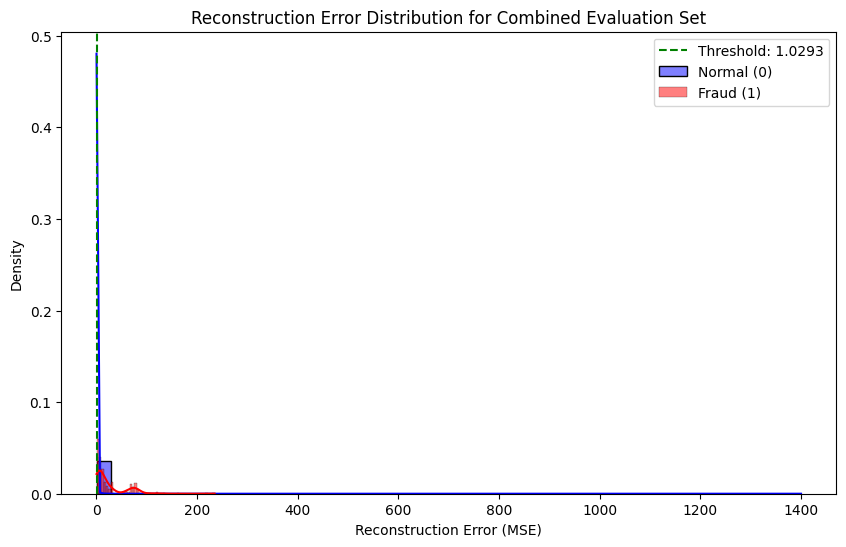

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Reconstruction Errors for Training Data (Normal)
predictions_train_major = autoencoder.predict(X_train_major_scaled)
mse_train_major = np.mean(np.power(X_train_major_scaled - predictions_train_major, 2), axis=1)

# 2. Determine Anomaly Threshold
# Use the 95th percentile of reconstruction errors from the normal training data
threshold = np.percentile(mse_train_major, 95) # This value might need tuning
print(f"Calculated Anomaly Threshold (95th percentile of training MSE): {threshold:.4f}")


# --- Evaluation for Training Data --- (to ensure it reconstructs normal data well)
print("\n--- Evaluation on Training Data (Cleaned Non-Fraudulent) ---")
predictions_train = autoencoder.predict(X_train_major_scaled)
mse_train = np.mean(np.power(X_train_major_scaled - predictions_train, 2), axis=1)

y_pred_train = (mse_train > threshold).astype(int)

print("Confusion Matrix (Training Data):")
print(confusion_matrix(y_train_normal, y_pred_train))
print("\nClassification Report (Training Data):")
print(classification_report(y_train_normal, y_pred_train, target_names=['Normal (0)', 'Anomaly (1)']))


# --- Evaluation for Validation Data --- (Unseen Normal Data)
print("\n--- Evaluation on Validation Data (Non-Fraudulent) ---")
predictions_val = autoencoder.predict(X_val_major_scaled)
mse_val = np.mean(np.power(X_val_major_scaled - predictions_val, 2), axis=1)

y_pred_val = (mse_val > threshold).astype(int)

print("Confusion Matrix (Validation Data):")
print(confusion_matrix(y_val_normal, y_pred_val))
print("\nClassification Report (Validation Data):")
print(classification_report(y_val_normal, y_pred_val, target_names=['Normal (0)', 'Anomaly (1)']))


# --- Evaluation for Combined Test Data --- (Validation Normal + Fraudulent Test)
print("\n--- Evaluation on Combined Evaluation Data (Validation + Fraudulent Test) ---")
predictions_combined_eval = autoencoder.predict(X_combined_eval_scaled)
mse_combined_eval = np.mean(np.power(X_combined_eval_scaled - predictions_combined_eval, 2), axis=1)

y_pred_combined_eval = (mse_combined_eval > threshold).astype(int)

print("Confusion Matrix (Combined Evaluation Data):")
print(confusion_matrix(y_combined_eval, y_pred_combined_eval))
print("\nClassification Report (Combined Evaluation Data):")
print(classification_report(y_combined_eval, y_pred_combined_eval, target_names=['Normal (0)', 'Fraud (1)']))

# Plotting reconstruction error distribution for combined eval set
plt.figure(figsize=(10, 6))
sns.histplot(mse_combined_eval[y_combined_eval == 0], bins=50, kde=True, color='blue', label='Normal (0)', stat='density')
sns.histplot(mse_combined_eval[y_combined_eval == 1], bins=50, kde=True, color='red', label='Fraud (1)', stat='density')
plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Reconstruction Error Distribution for Combined Evaluation Set')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.show()


### Visualizing the Confusion Matrix for the Combined Evaluation Set

To better understand the model's performance, let's visualize the confusion matrix as a heatmap. This will clearly show the counts of true positives, true negatives, false positives, and false negatives.

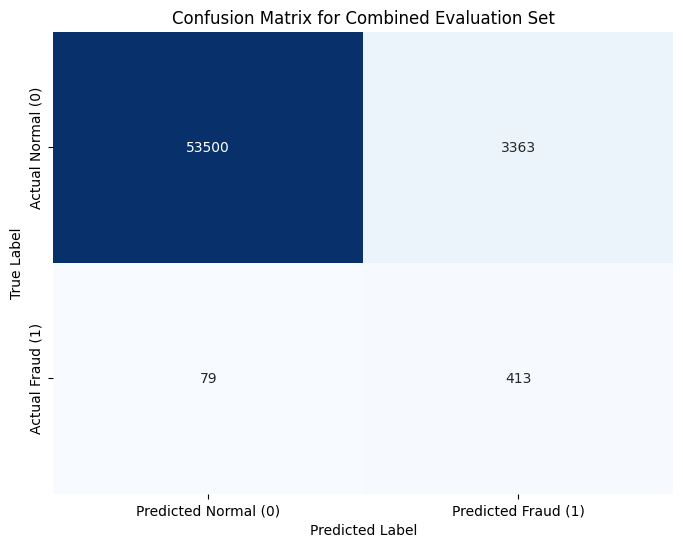

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for the combined evaluation set
cm_combined_eval = confusion_matrix(y_combined_eval, y_pred_combined_eval)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_combined_eval, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Normal (0)', 'Actual Fraud (1)'])
plt.title('Confusion Matrix for Combined Evaluation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [16]:
from sklearn.metrics import classification_report

print("\nClassification Report (Combined Evaluation Data - Test Set):")
print(classification_report(y_combined_eval, y_pred_combined_eval, target_names=['Normal (0)', 'Fraud (1)']))


Classification Report (Combined Evaluation Data - Test Set):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.94      0.97     56863
   Fraud (1)       0.11      0.84      0.19       492

    accuracy                           0.94     57355
   macro avg       0.55      0.89      0.58     57355
weighted avg       0.99      0.94      0.96     57355

